AttributeError: 'Chopper' object has no attribute 'centers_to_edges'

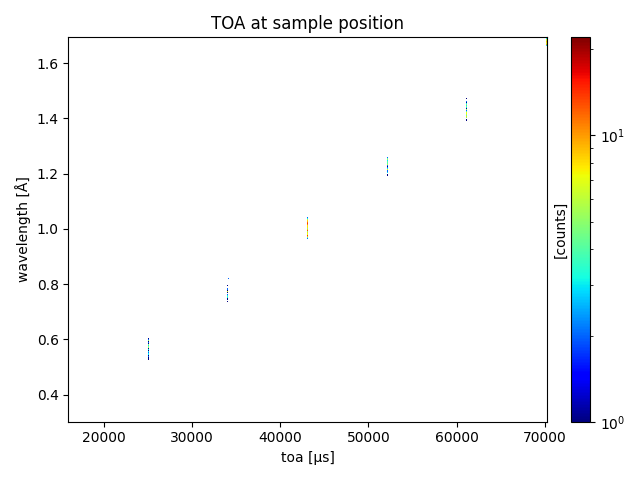

In [2]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from trex.instrument import Instrument
import plopp as pp


central_wavelength = 1 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 8
T_OFFSET = sc.scalar(1700.0e-6, unit="s")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

# Histogram and plot

fig, ax = plt.subplots()
toa_sample = events_at_sample.hist(wavelength=800, toa=1000).plot(\
    norm='log', cbar=True, ax=ax,cmap='jet', title='TOA at sample position')

toa_centers = trex.calculate_toa_at("monitor_sample",RRM=True)
toa_bin_edges = trex.bw1.centers_to_edges(toa_centers)
for edge in toa_bin_edges:
    vline = ax.axvline(x = edge.values, c = 'k', linestyle='--',label = 'bin edges')


toa_binned = events_at_sample.bin(toa=toa_bin_edges)
# Weighted mean of wavelength inside each bin
wavelength_mu = (
    toa_binned.bins.data * toa_binned.bins.coords['wavelength']
).bins.sum() / toa_binned.bins.sum()

# Variance of wavelengths inside each bin
wavelength_var = (
    toa_binned.bins.data * (toa_binned.bins.coords['wavelength'] - wavelength_mu) ** 2
) / toa_binned.bins.sum()

# TOA mean of wavelength inside each bin
toa_mu = (
    toa_binned.bins.data * toa_binned.bins.coords['toa']
).bins.sum() / toa_binned.bins.sum()

# Variance of TOA inside each bin
toa_var = (
    toa_binned.bins.data * (toa_binned.bins.coords['toa'] - toa_mu) ** 2
) / toa_binned.bins.sum()

ebplot=ax.errorbar(x=toa_mu.values, xerr= sc.sqrt(toa_var.hist()).values,
            y=wavelength_mu.values, yerr=sc.sqrt(wavelength_var.hist()).values, 
            fmt='ok', linestyle='', mfc='none',label='weighted by counts')
ax.grid(alpha=0.6)
ax.set_xlim((toa_bin_edges.min().values, toa_bin_edges.max().values))
ax.legend(handles=[vline,ebplot])
fig.tight_layout()

In [3]:
toa_m3 = trex.calculate_toa_at('monitor3',RRM=True)
toa_m3_edge = trex.centers_to_edges(toa_m3)
toa_det = trex.calculate_toa_at('detector',RRM=True)
toa_det_edge = trex.centers_to_edges(toa_det)

toa_bin = sc.linspace('toa', toa_m3_edge.min(), toa_det_edge.max(), num=3000, unit='us')
hist_m3 = res.detectors['monitor 3'].toa.data.hist(toa=toa_bin) 
hist_det = res.detectors['detector'].toa.data.hist(toa=toa_bin)

pp.plot({'monitor 3': hist_m3, 'detector': hist_det},grid=True) # type: ignore

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…